In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import umap

In [2]:
# reading in the words.txt
with open('../data/words.txt', 'r') as f:
    words = f.read().splitlines()

# convert to numpy array
words = np.array(words)
words

array(['dog', 'cat', 'horse', 'cow', 'pig', 'sheep', 'goat', 'rabbit',
       'deer', 'wolf', 'fox', 'bear', 'lion', 'tiger', 'elephant',
       'giraffe', 'zebra', 'monkey', 'gorilla', 'dolphin', 'whale', 'bat',
       'mouse', 'rat', 'squirrel', 'eagle', 'hawk', 'owl', 'parrot',
       'penguin', 'flamingo', 'sparrow', 'robin', 'crow', 'pigeon',
       'peacock', 'toucan', 'pelican', 'heron', 'swan', 'duck', 'goose',
       'ostrich', 'turkey', 'woodpecker', 'hummingbird', 'seagull',
       'cardinal', 'bluejay', 'falcon', 'snake', 'lizard', 'crocodile',
       'alligator', 'turtle', 'gecko', 'iguana', 'chameleon', 'frog',
       'toad', 'salamander', 'newt', 'cobra', 'python', 'komodo', 'shark',
       'salmon', 'tuna', 'clownfish', 'goldfish', 'trout', 'bass',
       'octopus', 'squid', 'jellyfish', 'lobster', 'crab', 'shrimp',
       'starfish', 'seahorse', 'butterfly', 'bee', 'ant', 'mosquito',
       'ladybug', 'dragonfly', 'grasshopper', 'beetle', 'moth', 'cricket',
       'app

In [3]:
len(words)

633

In [4]:
# encode vectors
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(words, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
# checking if embeddings are nan
np.any(np.isnan(embeddings))

np.False_

In [6]:
# normalize the embeddings
embeddings = np.asarray(embeddings, dtype=np.float32)
embeddings = normalize(embeddings, norm="l2", axis=1)

In [7]:
# run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=4, min_samples=4, metric='euclidean')
cluster_labels = clusterer.fit_predict(embeddings)

In [17]:
from collections import defaultdict

clusters = {i: label for i, label in enumerate(cluster_labels)}

In [18]:
len(clusters)

633

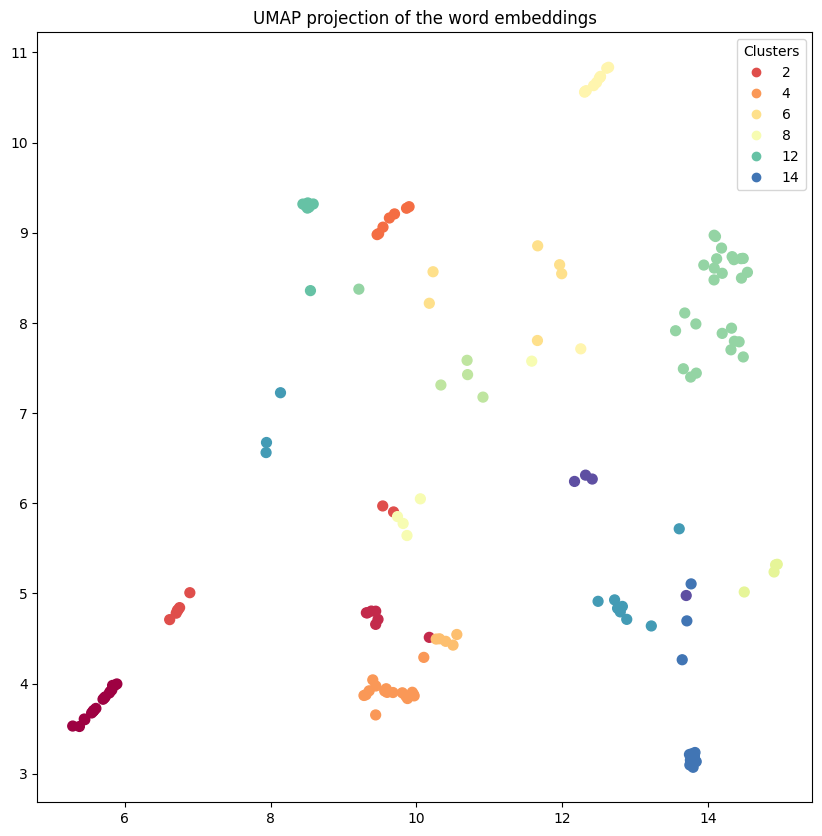

In [10]:
# visualize with umap
reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, metric='euclidean')
embedding_2d = reducer.fit_transform(embeddings)

cluster_labels = np.array(cluster_labels)

mask = (cluster_labels != -1)
filtered_labels = cluster_labels[mask]

plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    embedding_2d[mask, 0],
    embedding_2d[mask, 1],
    c=filtered_labels,
    cmap='Spectral',
    s=50
)

handles, labels = scatter.legend_elements()

new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if "0" not in l and "-1" not in l:
        new_handles.append(h)
        new_labels.append(l)

plt.legend(new_handles, new_labels, title="Clusters")
plt.title('UMAP projection of the word embeddings')
plt.show()

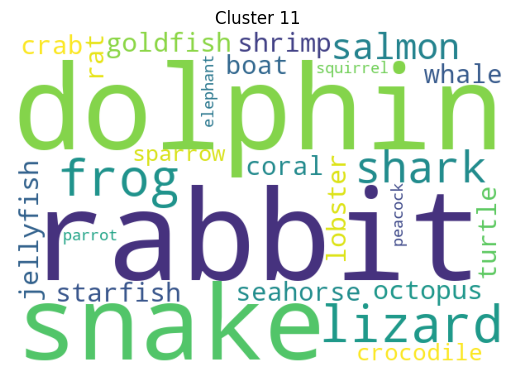

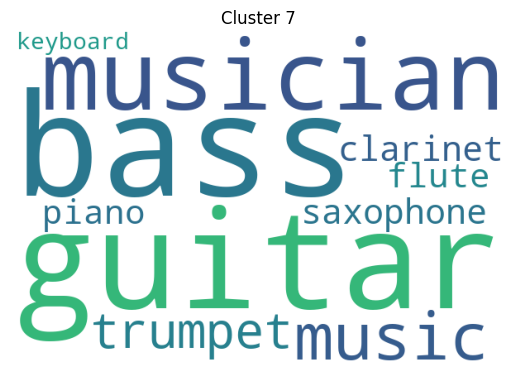

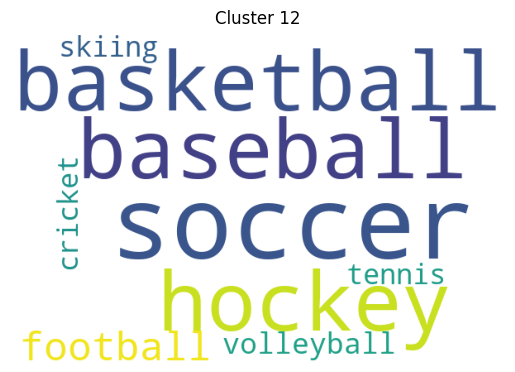

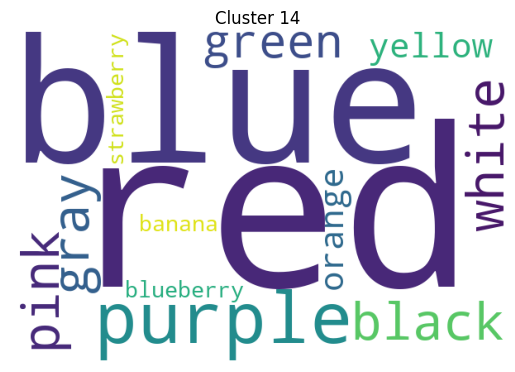

In [11]:
from wordcloud import WordCloud

probs = clusterer.probabilities_

# only first 5 clusters
# ignore first noise cluster
cluster_ids = list(clusters.keys())[1:5]

# for each cluster id, make the word cloud
for cid in cluster_ids:
    freqs = {}

    for i in range(len(words)):
        if cluster_labels[i] != cid:
            continue
            # weighing based on freq
        freqs[words[i]] = probs[i]

    wc = WordCloud(width=600, height=400, background_color="white")
    wc = wc.generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Cluster {cid}")
    plt.show()

In [12]:
import pandas as pd

cluster_df = pd.DataFrame({
    'cluster_id': list(clusters.keys()),
    'words': list(clusters.values())
})
cluster_df.to_pickle("../data/cluster.pkl")

In [13]:
clusters

defaultdict(list,
            {np.int64(-1): [np.str_('dog'),
              np.str_('cat'),
              np.str_('horse'),
              np.str_('cow'),
              np.str_('pig'),
              np.str_('sheep'),
              np.str_('goat'),
              np.str_('deer'),
              np.str_('wolf'),
              np.str_('fox'),
              np.str_('bear'),
              np.str_('lion'),
              np.str_('tiger'),
              np.str_('giraffe'),
              np.str_('zebra'),
              np.str_('monkey'),
              np.str_('gorilla'),
              np.str_('bat'),
              np.str_('mouse'),
              np.str_('eagle'),
              np.str_('hawk'),
              np.str_('owl'),
              np.str_('penguin'),
              np.str_('flamingo'),
              np.str_('robin'),
              np.str_('crow'),
              np.str_('pigeon'),
              np.str_('toucan'),
              np.str_('pelican'),
              np.str_('heron'),
              n

In [14]:
# save embeddings to a pickle
embeddings_df = pd.DataFrame(embeddings)
embeddings_df['word'] = words
embeddings_df.to_pickle("../data/embeddings.pkl")

In [15]:
embeddings_df.shape

(633, 385)

In [16]:
assert len(clusters) == len(embeddings)

AssertionError: 